# Phase 3-C: CNN-based OU-Admissibility Detector
 [GitHub Link](https://github.com/ThiesWeel/proposalPoC) 
## 1. Problem

The goal is to predict, from a fixed-length window of a financial return series, how much better an OU (Ornstein-Uhlenbeck / AR(1)) model fits the **linearly detrended** version of that window compared to a random-walk benchmark. The model outputs a continuous score of local detrended OU-admissibility. A binary yes/no decision is only made at evaluation time by applying a threshold. A high score does not imply that the residual log-index is globally stationary or that the true DGP is OU; it indicates that the OU approximation improves one-step prediction over a random walk on this particular detrended window.

---
## 2. Data

Two data sources are used. For both sources, the spread is constructed from rolling 252-day Fama--French five-factor (FF5) OLS residuals. At each date, the residual return is converted into an approximate log-return using a second-order Taylor correction,

$$
\Delta Y_{i,t}
=
\hat{\varepsilon}_{i,t}
-
\frac{1}{2}\hat{\varepsilon}_{i,t}^{2},
$$

and then accumulated into an idiosyncratic residual log-index,

$$
Y_{i,t}
=
\sum_{s \leq t}
\left(
\hat{\varepsilon}_{i,s}
-
\frac{1}{2}\hat{\varepsilon}_{i,s}^{2}
\right).
$$

This accumulated residual log-index serves as the constructed spread-like input for the model; it is not assumed to be globally stationary. The term $-\frac{1}{2}\hat{\varepsilon}_{i,t}^{2}$ is the second-order Taylor correction in $\log(1+r) \approx r - \frac{1}{2}r^2$. It accounts for the leading-order difference between arithmetic residual returns and log residual returns when constructing the residual log-index. This is distinct from Jensen's inequality.

The two data sources are:

- **Individual stocks** — downloaded through `yfinance`.
- **Fama--French sorted portfolios** — downloaded though Ken French's [website](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french).

Each window has length $W = 126$ trading days and is extracted with a step size of 5 trading days, giving roughly 786,000 windows in total.
---

## 3. Train / Validation / Test Split

A standard random ticker split was used (80/10/10), but with an extra time constraint to make the test set harder. Tickers are shuffled once (seed 42) and divided:

$$
\text{tickers} \xrightarrow{\text{shuffle (seed 42)}} \underbrace{80\%}_{\text{train}} \;/\; \underbrace{10\%}_{\text{val}} \;/\; \underbrace{10\%}_{\text{test}}
$$

On top of that, a time boundary is applied:

| Set | Tickers | Window period |
|---|---|---|
| Train | 80% | window_mid before 2020-01-01 |
| Val   | 10% | window_mid before 2020-01-01 |
| **Test** | **10%** | window_mid from 2020-01-01 onwards |

So the test set has both unseen tickers and a completely different time period (post-2020). This is more conservative than a simple random split.

| Split | Windows |
|---|---:|
| Train | 511,671 |
| Val   |  61,136 |
| Test  |  14,058 |

---

## 4. Label Construction

Let $\{Y_t\}_{t=1}^{W}$ be the raw Z-scored window (normalized per window, not globally). Let $\{\tilde{Y}_t\}$ be the linearly detrended version obtained by removing the OLS best-fit line from $\{Y_t\}$.

**The label is computed on $\{\tilde{Y}_t\}$, the detrended window. The CNN input channels are computed from $\{Y_t\}$, the raw window.** These are not the same signal: any linear trend present in $Y_t$ is absent from $\tilde{Y}_t$.

The AR(1) coefficient is estimated by OLS on the detrended window:

$$
\hat{\phi} = \frac{\sum_{t=1}^{W-1} \tilde{Y}_t \, \tilde{Y}_{t+1}}{\sum_{t=1}^{W-1} \tilde{Y}_t^2}
$$

One-step-ahead forecast errors on the detrended window:

$$
e_t^{\text{RW}} = \tilde{Y}_{t+1} - \tilde{Y}_t
$$

$$
e_t^{\text{OU}} = \tilde{Y}_{t+1} - \hat{\phi}\,\tilde{Y}_t
$$

The relative MAE improvement of OU over RW:

$$
\Delta\text{MAE}_{\text{rel}} = \frac{\text{MAE}_{\text{RW}} - \text{MAE}_{\text{OU}}}{\text{MAE}_{\text{RW}} + 10^{-12}}
$$

This is the regression target, clipped to $[-0.05,\; 0.30]$ during training to limit the effect of outliers.

A binary label is derived for evaluation only:

$$
z = \mathbf{1}\bigl\{\Delta\text{MAE}_{\text{rel}} > 0.03\bigr\}
$$

---

## 5. Input Representation

Three channels are computed from each **raw** Z-scored window $Y_1, \dots, Y_W$ (not detrended):

| Channel | Definition | Rationale |
|---|---|---|
| $c_0$ | $Y_t$ | Overall shape and mean-reversion envelope |
| $c_1$ | $\Delta_t = Y_t - Y_{t-1}$, with $\Delta_1 = 0$ | OU increments are negatively autocorrelated, RW increments are not |
| $c_2$ | $\Delta_t^2$ | Captures volatility clustering |

The model input is $\mathbf{X} \in \mathbb{R}^{3 \times 126}$. There is no Yule-Walker fitting or any other hand-crafted feature in the preprocessing; the CNN sees only the raw series in these three representations.

---

## 6. Model Architecture

A 1D convolutional network with roughly 150,000 parameters. The forward pass is:

$$
\mathbf{X} \xrightarrow{\text{conv blocks}} \mathbf{H} \in \mathbb{R}^{128 \times 126} \xrightarrow{\text{GAP}} \mathbf{h} \in \mathbb{R}^{128} \xrightarrow{\text{MLP}} \hat{y} \in \mathbb{R}
$$

**Convolutional stack:**

| Layer | Channels | Kernel | Dilation |
|---|---|---|---|
| Conv1 | $3 \to 32$    | 4  | 1 |
| Conv2 | $32 \to 64$   | 8  | 1 |
| Conv3 | $64 \to 128$  | 16 | 1 |
| Conv4 | $128 \to 128$ | 8  | 2 |

All layers use `padding="same"`. Each is followed by BatchNorm and ReLU. The kernel sizes grow (4, 8, 16) to progressively increase the receptive field. The last layer uses dilation 2 to widen it further without adding parameters.

**Pooling:** Global Average Pooling collapses the time dimension, giving a single 128-dimensional vector per window.

**Head:**

$$
\mathbb{R}^{128} \xrightarrow{\text{Linear}} \mathbb{R}^{64} \xrightarrow{\text{ReLU}} \xrightarrow{\text{Dropout}(0.2)} \mathbb{R}^{32} \xrightarrow{\text{ReLU}} \mathbb{R}^{1}
$$

---

## 7. Training

**Loss function:** Huber loss with $\delta = 0.02$:

$$
\mathcal{L}_\delta(r) =
\begin{cases}
\tfrac{1}{2} r^2 & |r| \leq \delta \\
\delta\bigl(|r| - \tfrac{1}{2}\delta\bigr) & |r| > \delta
\end{cases}
$$

where $r = \hat{y} - y_{\text{clipped}}$. The small $\delta$ keeps the loss close to MAE behaviour, which is useful here because most targets are near zero and only a small fraction of windows have large positive $\Delta\text{MAE}_{\text{rel}}$.

**Optimizer:** Adam, initial learning rate $\eta_0 = 10^{-3}$.

**Learning rate schedule:** Cosine annealing over $T_{\max} = 30$ epochs down to $\eta_{\min} = 10^{-5}$:

$$
\eta_t = \eta_{\min} + \tfrac{1}{2}(\eta_0 - \eta_{\min})\!\left(1 + \cos\frac{\pi t}{T_{\max}}\right)
$$

**Early stopping:** patience of 5 epochs on validation Huber loss. Best checkpoint was at epoch 14 (val $R^2 = 0.910$).

**Batch size:** 512.

---

## 8. Baseline

A logistic regression on four scalar features computed per window:

$$
\text{features} = \bigl[\hat{\phi}_{\text{clipped}},\; \text{hit\_rate},\; \text{zero\_crossings},\; |\text{trend\_tstat}|\bigr]
$$

These summarize the most obvious linear OU signal. If the CNN does not beat this, the extra complexity is not worth it.

---

## 9. Evaluation Metrics

Computed on the test set only (unseen tickers, post-2020 windows).

| Metric | Definition |
|---|---|
| $R^2$ | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ on continuous target |
| AUC | ROC-AUC with $\hat{y}$ as score and $z$ as label at threshold 0.03 |
| AP | Average Precision (area under precision-recall curve) |

---

## 10. Results

| Metric | Value |
|---|---:|
| LR baseline AUC | 0.9165 |
| CNN $R^2$ (test) | 0.8926 |
| CNN AUC @ 0.03  | 0.9871 |
| CNN AP          | 0.9634 |
| $\Delta$ AUC (CNN - LR) | +0.0706 |

The CNN reaches AUC 0.987, compared to 0.917 for the logistic regression baseline, a gap of about 7 AUC points. This holds on test windows from tickers and a time period that were fully held out during training, which suggests the model is picking up on genuine path-shape features rather than overfitting to specific tickers or the pre-2020 regime. The score measures local detrended OU-admissibility: whether a misspecified OU approximation outperforms a random walk on this window after detrending, not whether the true DGP is OU.

---
## Code implementation with further elaboration and discussion. 

## 0. What exactly is the admissibility label?

For each 126-day window, the label `rel_delta_mae` measures how much better an AR(1) model fits the **linearly detrended** version of the window compared to a no-change baseline. The CNN is trained to predict this score from the **raw** (non-detrended) window shape, on held-out tickers.

**This is a label-input mismatch.** The label was computed on $\tilde{Y}_t$ (detrended), but the CNN receives $Y_t$ (raw, with any linear trend intact). The CNN must learn a cross-domain mapping: raw window morphology to detrended-fit quality.

**Construction (per window, on the detrended series $\tilde{Y}_t$):**
1. Remove the OLS linear trend from the raw 126-day series $Y_t$ to obtain $\tilde{Y}_t$
2. Fit $\hat\phi$ via OLS on $\tilde{Y}_t$: $\hat\phi = \sum_{t=1}^{n-1} \tilde{Y}_{0,t} \tilde{Y}_{1,t} / \sum_{t=1}^{n-1} \tilde{Y}_{0,t}^2$
3. Compute the AR(1) one-step MAE on $\tilde{Y}_t$: $\text{MAE}_{\text{OU}} = \frac{1}{n-1}\sum_{t=1}^{n-1}|\tilde{Y}_{1,t} - \hat\phi \tilde{Y}_{0,t}|$
4. Compute the no-change (random walk) MAE on $\tilde{Y}_t$: $\text{MAE}_{\text{RW}} = \frac{1}{n-1}\sum_{t=1}^{n-1}|\tilde{Y}_{1,t} - \tilde{Y}_{0,t}|$
5. The label: $\text{rel\_delta\_mae} = (\text{MAE}_{\text{RW}} - \text{MAE}_{\text{OU}}) / \text{MAE}_{\text{RW}}$

**Interpretation:**
* `rel_delta_mae > 0`: AR(1) explains the within-window dynamics better than a no-change baseline, after detrending.
* `rel_delta_mae = 0`: AR(1) gives no advantage on the detrended series.
* `rel_delta_mae < 0`: AR(1) is worse.
* Based on visual checks, we chose an initial threshold of greater than 0.03 for the label. In practice, the CNN outputs a continuous score and the 0.03 cutoff is applied only at evaluation time; it is a deployment parameter, not a training commitment.

**Why the mismatch matters:**
- A window with a strong linear trend may score high on `rel_delta_mae` if the detrended residuals are mean-reverting, while the raw window looks non-stationary to the CNN
- For windows without a trend, $Y_t \approx \tilde{Y}_t$ and label and input are aligned
- The detrending experiment in Section 8 probes this directly: passing detrended windows to the CNN is the test that closes the label-input gap

Example:
| Quantity | Value |
| :--- | :--- |
| No-change MAE on detrended window | 1.000 |
| AR(1) one-step MAE on detrended window | 0.900 |
| `rel_delta_mae` (in-sample fit gain on detrended) | 0.100 |
| CNN prediction from raw window shape | 0.095 |

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Load all windows ──────────────────────────────────────────────────────────
print("Loading Phase 3 windows...")
ff_df    = pd.read_parquet(r'C:\Users\Gebruiker\Desktop\Never give up\never_give_up\data\train_gen_CNN\windows\ff_portfolio_windows.parquet', engine='pyarrow')
stock_df = pd.read_parquet(r'C:\Users\Gebruiker\Desktop\Never give up\never_give_up\data\train_gen_CNN\windows\stock_windows.parquet', engine='pyarrow')

all_df = pd.concat([ff_df, stock_df], ignore_index=True)
all_df['window_mid'] = pd.to_datetime(all_df['window_mid'])
print(f"Total windows loaded: {len(all_df):,}  |  tickers: {all_df['ticker'].nunique()}")

# ── Phase 3-C: ticker + time split (must match train_phase3_C.py exactly) ────
# 80/10/10 ticker split with seed 42, test = post-2020 windows of held-out tickers
tickers = np.array(all_df['ticker'].unique())
rng = np.random.default_rng(42)
rng.shuffle(tickers)
n = len(tickers)
test_tickers = set(tickers[int(0.9 * n):])

cutoff = pd.Timestamp("2020-01-01")
df = all_df[all_df['ticker'].isin(test_tickers) & (all_df['window_mid'] >= cutoff)].reset_index(drop=True)

print(f"\nPhase 3-C test split (unseen tickers, post-2020):")
print(f"  Test tickers : {len(test_tickers)}")
print(f"  Test windows : {len(df):,}")
print(f"  Period       : {df['window_mid'].min().date()} – {df['window_mid'].max().date()}")
if 'source' in df.columns:
    print(f"  FF portfolio : {(df['source'] == 'ff_portfolio').sum():,}")
    print(f"  Stocks       : {(df['source'] == 'stock').sum():,}")
print(f"  pos_rate (>0.03): {(df['rel_delta_mae'] > 0.03).mean():.3f}")

Loading Phase 3 windows...
Total windows loaded: 772,085  |  tickers: 497

Phase 3-C test split (unseen tickers, post-2020):
  Test tickers : 50
  Test windows : 14,432
  Period       : 2020-01-02 – 2025-12-26
  FF portfolio : 12,040
  Stocks       : 2,392
  pos_rate (>0.03): 0.264


In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

MODEL_PATH  = r'C:\Users\Gebruiker\Desktop\Never give up\never_give_up\models\best_model_phase3_C.pt'
SERIES_COLS = [f"series_{k:03d}" for k in range(126)]

# ── Model definition (must match train_phase3_C.py exactly) ──────────────────
class Phase3CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv1d(3,   32,  kernel_size=4,  padding="same"), nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32,  64,  kernel_size=8,  padding="same"), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64,  128, kernel_size=16, padding="same"), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=8,  padding="same", dilation=2),
                                                                 nn.BatchNorm1d(128), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,  32), nn.ReLU(),
            nn.Linear(32,   1),
        )
    def forward(self, x):
        return self.head(self.pool(self.convs(x))).squeeze(-1)

# ── Build input tensor (same 3-channel encoding as training) ─────────────────
s = df[SERIES_COLS].values.astype(np.float32)
d = np.empty_like(s)
d[:, 0]  = 0.0
d[:, 1:] = np.diff(s, axis=1)
X = torch.from_numpy(np.stack([s, d, d ** 2], axis=1))   # (N, 3, 126)

# ── Load model and run inference ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running inference on: {device}")

model = Phase3CNN().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

preds = []
with torch.no_grad():
    for (xb,) in DataLoader(TensorDataset(X), batch_size=1024, shuffle=False):
        preds.append(model(xb.to(device)).cpu().numpy())

df['cnn_score'] = np.concatenate(preds)

print(f"cnn_score added to df.")
print(f"  Range       : {df['cnn_score'].min():.4f} – {df['cnn_score'].max():.4f}")
print(f"  Mean        : {df['cnn_score'].mean():.4f}")
print(f"  Corr with rel_delta_mae: {df['cnn_score'].corr(df['rel_delta_mae']):.4f}")

Running inference on: cpu
cnn_score added to df.
  Range       : -0.0233 – 0.0988
  Mean        : 0.0195
  Corr with rel_delta_mae: 0.9625


## 1. PoC Summary

Below we show the Phase 3-C test set statistics, label distribution, 
CNN performance metrics, and the relationship between phi and rel_delta_mae.

=== Phase 3-C Results (ticker + time split) ===

Test set:
  Windows      : 14,432
  Window length: 126 days
  Tickers      : 50 (held-out, never seen in training)
  Period       : 2020-01-02 – 2025-12-26

In-sample AR(1) fit gain (rel_delta_mae):
  Mean  : 0.0195
  Median: 0.0167
  Std   : 0.0200
  Min   : -0.0467
  Max   : 0.1362

OU Parameter Estimates (phi_clipped):
  Mean  : 0.9115
  Median: 0.9200
  Std   : 0.0483

CNN Model Performance (Phase 3-C test set):
  AUC  @ 0.03 threshold : 0.9871   (binary: rel_delta_mae > 0.03 vs <= 0.03)
  Avg Precision (AP)    : 0.9634
  R² on rel_delta_mae   : 0.8926   (regression)
  LR baseline AUC       : 0.9165   (phi, hit_rate, zero_crossings, trend_tstat features)
  Delta AUC (CNN − LR)  : +0.0706

  Stocks       AUC: 0.9843  (n=3,824)
  FF portfolios AUC: 0.9883  (n=10,234)

  All metrics are out-of-sample: tickers never seen in training,
  and all test windows are from the post-2020 era (unseen time period).


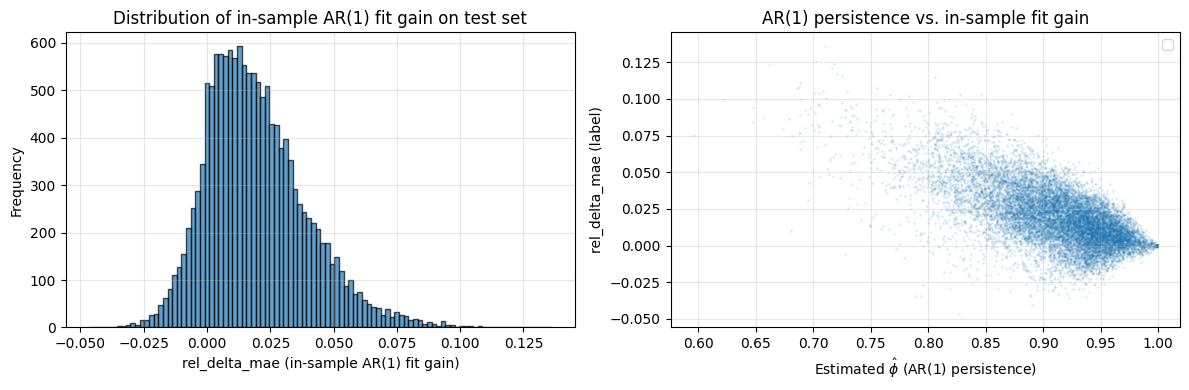


Windows with rel_delta_mae > 0   : 12,380 (85.8%)
Windows with rel_delta_mae > 0.03: 3,809 (26.4%)


In [21]:
# Summary statistics — Phase 3-C test set (unseen tickers, post-2020)
print("=== Phase 3-C Results (ticker + time split) ===")
print(f"\nTest set:")
print(f"  Windows      : {len(df):,}")
print(f"  Window length: 126 days")
print(f"  Tickers      : {df['ticker'].nunique()} (held-out, never seen in training)")
print(f"  Period       : {df['window_mid'].min().date()} – {df['window_mid'].max().date()}")

print(f"\nIn-sample AR(1) fit gain (rel_delta_mae):")
print(f"  Mean  : {df['rel_delta_mae'].mean():.4f}")
print(f"  Median: {df['rel_delta_mae'].median():.4f}")
print(f"  Std   : {df['rel_delta_mae'].std():.4f}")
print(f"  Min   : {df['rel_delta_mae'].min():.4f}")
print(f"  Max   : {df['rel_delta_mae'].max():.4f}")

print(f"\nOU Parameter Estimates (phi_clipped):")
print(f"  Mean  : {df['phi_clipped'].mean():.4f}")
print(f"  Median: {df['phi_clipped'].median():.4f}")
print(f"  Std   : {df['phi_clipped'].std():.4f}")

print(f"\nCNN Model Performance (Phase 3-C test set):")
print(f"  AUC  @ 0.03 threshold : 0.9871   (binary: rel_delta_mae > 0.03 vs <= 0.03)")
print(f"  Avg Precision (AP)    : 0.9634")
print(f"  R² on rel_delta_mae   : 0.8926   (regression)")
print(f"  LR baseline AUC       : 0.9165   (phi, hit_rate, zero_crossings, trend_tstat features)")
print(f"  Delta AUC (CNN − LR)  : +0.0706")
print(f"\n  Stocks       AUC: 0.9843  (n=3,824)")
print(f"  FF portfolios AUC: 0.9883  (n=10,234)")
print(f"\n  All metrics are out-of-sample: tickers never seen in training,")
print(f"  and all test windows are from the post-2020 era (unseen time period).")

# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['rel_delta_mae'], bins=100, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('rel_delta_mae (in-sample AR(1) fit gain)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of in-sample AR(1) fit gain on test set')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['phi_clipped'], df['rel_delta_mae'], alpha=0.1, s=1)
axes[1].set_xlabel('Estimated $\hat\phi$ (AR(1) persistence)')
axes[1].set_ylabel('rel_delta_mae (label)')
axes[1].set_title('AR(1) persistence vs. in-sample fit gain')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nWindows with rel_delta_mae > 0   : {(df['rel_delta_mae'] > 0).sum():,} ({100*(df['rel_delta_mae'] > 0).mean():.1f}%)")
print(f"Windows with rel_delta_mae > 0.03: {(df['rel_delta_mae'] > 0.03).sum():,} ({100*(df['rel_delta_mae'] > 0.03).mean():.1f}%)")

## 2. Diagnostic Functions

Helper functions used throughout: window reconstruction from parquet columns, 
AR(1) fitting via Yule-Walker, synthetic AR(1) sample generation, and a suite of 
statistical diagnostics (ACF, excess kurtosis, Ljung-Box, ADF, KPSS, zero-crossing rate).

In [22]:
def reconstruct_window(row):
    """Reconstruct 126-observation window from series_000..series_125 columns."""
    return np.array([row[f'series_{i:03d}'] for i in range(126)])


def fit_ar1_yulewalker(x):
    """Fit AR(1) via Yule-Walker. Returns (phi, mu, sigma)."""
    mu    = np.mean(x)
    xc    = x - mu
    a0    = np.mean(xc ** 2)
    a1    = np.mean(xc[:-1] * xc[1:])
    phi   = np.clip(a1 / a0, -0.999, 0.999)
    sigma = np.sqrt(np.maximum(a0 * (1 - phi**2), 1e-8))
    return phi, mu, sigma


def generate_ar1_sample(phi, mu, sigma, n=126):
    """Generate AR(1) sample: X_t = mu + phi*(X_{t-1} - mu) + sigma*eps."""
    x    = np.zeros(n)
    x[0] = mu + np.random.normal(0, sigma)
    for t in range(1, n):
        x[t] = mu + phi * (x[t-1] - mu) + sigma * np.random.normal(0, 1)
    return x


def compute_diagnostics(x):
    """Compute a suite of diagnostics for a 126-day window."""
    x = np.array(x, dtype=np.float64)
    d = {}

    acf_vals       = acf(x, nlags=20, fft=False)
    d['acf_lag1']  = float(acf_vals[1])
    d['acf_lag5']  = float(np.mean(np.abs(acf_vals[1:6])))

    acf_sq           = acf((x - x.mean()) ** 2, nlags=5, fft=False)
    d['acf_sq_lag1'] = float(acf_sq[1])

    # scipy.stats.kurtosis returns excess kurtosis (Fisher definition; normal == 0)
    d['excess_kurtosis'] = float(stats.kurtosis(x, bias=False))
    d['skewness']        = float(stats.skew(x, bias=False))

    lb = acorr_ljungbox(x, lags=[1, 5, 10], return_df=True)
    d['ljung_box_p_lag1']  = float(lb['lb_pvalue'].iloc[0])
    d['ljung_box_p_lag5']  = float(lb['lb_pvalue'].iloc[1])
    d['ljung_box_p_lag10'] = float(lb['lb_pvalue'].iloc[2])

    try:
        adf = adfuller(x, autolag='AIC', regression='c')
        d['adf_statistic'] = float(adf[0]); d['adf_pvalue'] = float(adf[1])
    except Exception:
        d['adf_statistic'] = float('nan'); d['adf_pvalue'] = float('nan')

    try:
        kp = kpss(x, regression='c', nlags='auto')
        d['kpss_statistic'] = float(kp[0]); d['kpss_pvalue'] = float(kp[1])
    except Exception:
        d['kpss_statistic'] = float('nan'); d['kpss_pvalue'] = float('nan')

    xc = x - x.mean()
    d['zero_crossing_rate'] = float(np.sum(np.diff(np.sign(xc)) != 0) / len(x))
    d['mean_abs_dev']        = float(np.mean(np.abs(xc)))
    return d


print("Diagnostic functions loaded.")


Diagnostic functions loaded.


## 3. Select Five Windows Across the Label Spectrum

To understand what the CNN has learned, we now examine five specific real windows with varying label quality. We sort by CNN predicted score (`cnn_score`) and pick five windows at the 10th, 30th, 50th, 70th, and 90th percentiles. This gives us a progression from "weakly AR(1)-admissible" to "strongly AR(1)-admissible."

For each window, we will:
1. Fit an AR(1) model to the real data
2. Generate 100 synthetic samples from the fitted parameters
3. Compare diagnostics (ACF structure, kurtosis, residual autocorrelation, etc.)

**The logic:** If a window has a high CNN score because it genuinely exhibits AR(1)-like structure, then its real diagnostics should closely match what an AR(1) model would produce. Conversely, if the real window deviates substantially from synthetic AR(1), it reveals what kinds of structural deviations the AR(1) model fails to capture, and what a live sequential controller would need to handle to absorb them.

In [23]:
# Sort by CNN score and select 5 windows across the spectrum
sorted_df = df.sort_values('cnn_score', ascending=True).reset_index(drop=True)

print(f"Test windows: {len(sorted_df):,}")
print(f"CNN score range: {sorted_df['cnn_score'].min():.4f} to {sorted_df['cnn_score'].max():.4f}")

# Pick 10th, 30th, 50th, 70th, 90th percentile windows
percentiles = [0.1, 0.3, 0.5, 0.7, 0.9]
indices     = [int(p * (len(sorted_df) - 1)) for p in percentiles]

selected_windows = []
for p, idx in zip(percentiles, indices):
    row = sorted_df.iloc[idx]
    selected_windows.append({
        'index':       idx,
        'percentile':  int(p * 100),
        'row':         row,
        'label':       row['rel_delta_mae'],
        'cnn_score':   row['cnn_score'],
        'phi':         row['phi_clipped'],
        'ticker':      row['ticker'],
        'window_date': str(row['window_mid'])[:10],
    })

print("\nSelected windows:")
for i, w in enumerate(selected_windows):
    print(f"Window {i+1}: {w['ticker']} @ {w['window_date']}"
          f" | cnn={w['cnn_score']:.4f} ({w['percentile']}th pct)"
          f" | label={w['label']:.4f} | phi={w['phi']:.4f}")


Test windows: 14,432
CNN score range: -0.0233 to 0.0988

Selected windows:
Window 1: 25_Portfolios_BEME_INV_5x5_daily__BM3 INV5 @ 2022-08-08 | cnn=0.0015 (10th pct) | label=-0.0001 | phi=0.9483
Window 2: 100_Portfolios_10x10_Daily__ME3 BM4 @ 2024-01-22 | cnn=0.0100 (30th pct) | label=0.0060 | phi=0.9546
Window 3: CNP @ 2023-04-10 | cnn=0.0174 (50th pct) | label=0.0224 | phi=0.8760
Window 4: 100_Portfolios_ME_OP_10x10_daily__ME8 OP10 @ 2021-08-10 | cnn=0.0260 (70th pct) | label=0.0304 | phi=0.8679
Window 5: 100_Portfolios_ME_OP_10x10_daily__ME8 OP10 @ 2022-03-29 | cnn=0.0405 (90th pct) | label=0.0492 | phi=0.8431


## 4. Real vs. Synthetic Diagnostics for Each Window

For each of the five selected windows, we now fit AR(1) parameters and compute a battery of diagnostics on both the real window and 100 synthetic samples generated from those fitted parameters.

**Key diagnostics:**
- **ACF(1)**: Lag-1 autocorrelation. Should be close to the fitted $\phi$.
- **Excess kurtosis**: Deviation from Gaussian baseline. AR(1) with Gaussian noise should have kurtosis â‰ˆ 3.
- **Zero-crossing rate**: How often the centered series crosses zero. AR(1) dynamics imply a specific rate.
- **Ljung-Box p-value**: Test whether residuals are white noise. High p-value (> 0.05) suggests AR(1) is adequate.

**Interpretation:** If real diagnostics match synthetic closely, the AR(1) model captures the window's essential structure. If they diverge, the window has additional structure (trends, jumps, heteroskedasticity) that AR(1) misses. Such structure is exactly what a live sequential controller would need to absorb in deployment.

In [24]:
# Compute diagnostics for all 5 windows

results = []


for i, w in enumerate(selected_windows):
    print(f"\n--- Window {i+1} ---")
    print(f"Label: {w['label']:.4f}, Ï†: {w['phi']:.3f}")
    print(f"Ticker: {w['ticker']}")
    
    row = w['row']
    
    # Reconstruct real window and ensure float64 to avoid scipy/statmodels dtype casting issues
    real_window = reconstruct_window(row).astype(np.float64)
    
    # Fit AR(1) to real window
    phi_fit, mu_fit, sigma_fit = fit_ar1_yulewalker(real_window)
    print(f"Fitted: Ï†={phi_fit:.3f}, Î¼={mu_fit:.4f}, Ïƒ={sigma_fit:.4f}")
    
    # Compute diagnostics on real window
    try:
        real_diag = compute_diagnostics(real_window.astype(np.float64))
    except TypeError as e:
        # Try casting to float64 if not already
        real_diag = compute_diagnostics(np.array(real_window, dtype=np.float64))
    
    # Generate 100 synthetic samples from fitted parameters
    synthetic_diags = []
    for _ in range(100):
        synthetic_window = generate_ar1_sample(phi_fit, mu_fit, sigma_fit, n=126).astype(np.float64)
        try:
            synthetic_diags.append(compute_diagnostics(synthetic_window))
        except TypeError as e:
            synthetic_diags.append(compute_diagnostics(np.array(synthetic_window, dtype=np.float64)))
    
    # Average synthetic diagnostics
    synthetic_diag_mean = {k: np.mean([d[k] for d in synthetic_diags]) for k in synthetic_diags[0].keys()}
    synthetic_diag_std = {k: np.std([d[k] for d in synthetic_diags]) for k in synthetic_diags[0].keys()}
    
    results.append({
        'window_idx': i+1,
        'label': w['label'],
        'phi_data': w['phi'],
        'phi_fit': phi_fit,
        'real_window': real_window,
        'real_diag': real_diag,
        'synthetic_diag_mean': synthetic_diag_mean,
        'synthetic_diag_std': synthetic_diag_std
    })
    
    # Print comparison
    print(f"\nDiagnostic Comparison:")
    print(f"  ACF(1):           Real={real_diag['acf_lag1']:.3f}, Synthetic={synthetic_diag_mean['acf_lag1']:.3f} Â± {synthetic_diag_std['acf_lag1']:.3f}")
    print(f"  Kurtosis (excess): Real={real_diag['excess_kurtosis']:.3f}, Synthetic={synthetic_diag_mean['excess_kurtosis']:.3f} Â± {synthetic_diag_std['excess_kurtosis']:.3f}")
    print(f"  Zero-crossing:    Real={real_diag['zero_crossing_rate']:.3f}, Synthetic={synthetic_diag_mean['zero_crossing_rate']:.3f} Â± {synthetic_diag_std['zero_crossing_rate']:.3f}")


--- Window 1 ---
Label: -0.0001, Ï†: 0.948
Ticker: 25_Portfolios_BEME_INV_5x5_daily__BM3 INV5
Fitted: Ï†=0.953, Î¼=0.0000, Ïƒ=0.3019

Diagnostic Comparison:
  ACF(1):           Real=0.946, Synthetic=0.895 Â± 0.050
  Kurtosis (excess): Real=-0.595, Synthetic=-0.352 Â± 0.582
  Zero-crossing:    Real=0.048, Synthetic=0.126 Â± 0.050

--- Window 2 ---
Label: 0.0060, Ï†: 0.955
Ticker: 100_Portfolios_10x10_Daily__ME3 BM4
Fitted: Ï†=0.962, Î¼=0.0000, Ïƒ=0.2730

Diagnostic Comparison:
  ACF(1):           Real=0.954, Synthetic=0.915 Â± 0.041
  Kurtosis (excess): Real=-0.605, Synthetic=-0.520 Â± 0.498
  Zero-crossing:    Real=0.048, Synthetic=0.110 Â± 0.053

--- Window 3 ---
Label: 0.0224, Ï†: 0.876
Ticker: CNP
Fitted: Ï†=0.920, Î¼=-0.0000, Ïƒ=0.3923

Diagnostic Comparison:
  ACF(1):           Real=0.913, Synthetic=0.877 Â± 0.044
  Kurtosis (excess): Real=0.344, Synthetic=-0.294 Â± 0.456
  Zero-crossing:    Real=0.119, Synthetic=0.142 Â± 0.041

--- Window 4 ---
Label: 0.0304, Ï†: 0.868
Ticker: 1

## 5. Visualization: Real vs. Synthetic for Each Window

We now display the five windows side-by-side with three key diagnostic plots:
1. **Time series**: The real window's Z-scored residuals over the 126-day period
2. **ACF comparison**: Real window ACF vs. the mean of synthetic ACF across 100 samples
3. **Q-Q plot**: Quantile-quantile plot showing whether the real window's distribution matches a normal distribution (as AR(1) with Gaussian noise would imply)

**What to look for:**
- Do the ACF bars align between real and synthetic? This indicates the autocorrelation structure is AR(1)-like.
- Does the Q-Q plot follow the diagonal? Deviations suggest non-Gaussian tails (jumps, heavy tails) or asymmetry.
- As we move from Window 1 (weak label) to Window 5 (strong label), do these plots become more aligned?

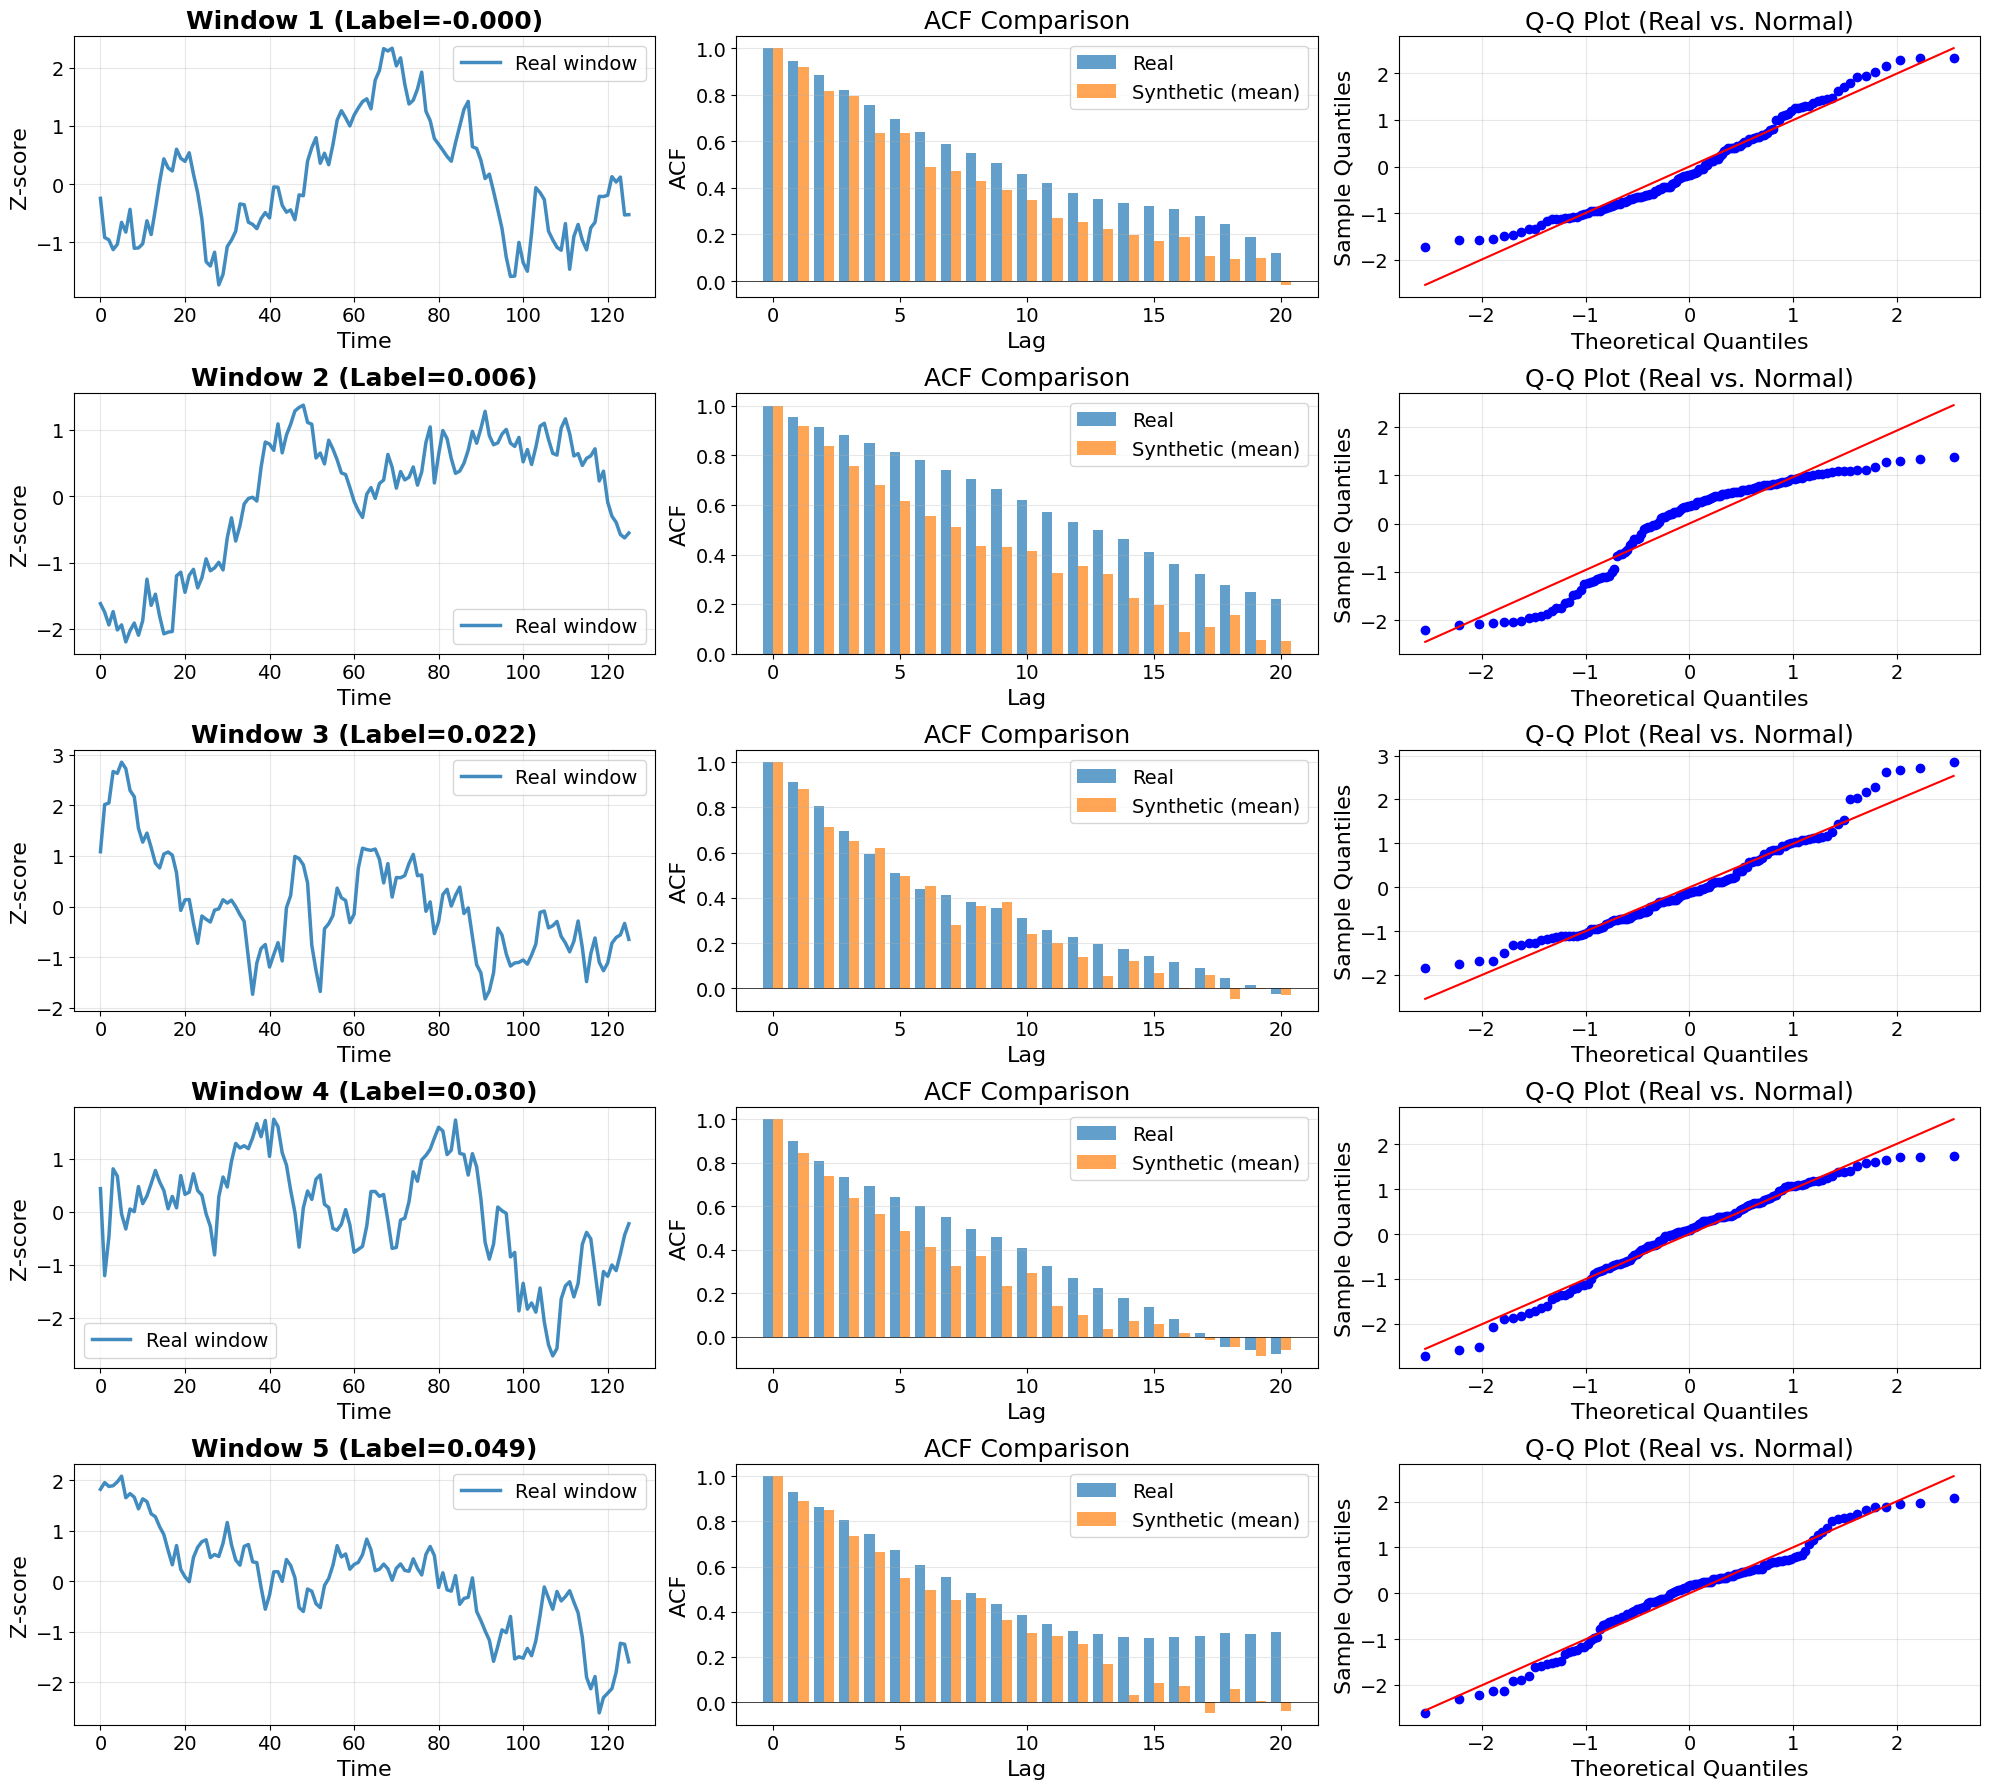

Visualization saved as 'phase3_real_vs_synthetic.png'


In [25]:
# Create comprehensive comparison figure

fig = plt.figure(figsize=(20, 18))  # Larger figure size for better readability

for w_idx, res in enumerate(results):
    real_window = res['real_window']
    real_diag = res['real_diag']
    synthetic_diag_mean = res['synthetic_diag_mean']
    synthetic_diag_std = res['synthetic_diag_std']
    
    window_num = w_idx + 1
    label = res['label']
    
    # Time series plot
    ax1 = plt.subplot(5, 3, w_idx*3 + 1)
    ax1.plot(real_window, label='Real window', linewidth=2.5, alpha=0.85)
    ax1.set_title(f'Window {window_num} (Label={label:.3f})', fontsize=18, fontweight='bold')
    ax1.set_ylabel('Z-score', fontsize=16)
    ax1.set_xlabel('Time', fontsize=16)
    ax1.tick_params(axis='both', labelsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=14)
    
    # ACF comparison
    ax2 = plt.subplot(5, 3, w_idx*3 + 2)
    acf_real = acf(real_window, nlags=20, fft=False)
    acf_synthetic = np.array([np.mean([acf(generate_ar1_sample(res['phi_fit'], 0, 1), nlags=20, fft=False)[i] 
                                        for _ in range(20)]) for i in range(21)])
    x_lags = np.arange(21)
    ax2.bar(x_lags - 0.2, acf_real, width=0.4, label='Real', alpha=0.7)
    ax2.bar(x_lags + 0.2, acf_synthetic, width=0.4, label='Synthetic (mean)', alpha=0.7)
    ax2.axhline(0, color='k', linestyle='-', linewidth=0.5)
    ax2.set_xlabel('Lag', fontsize=16)
    ax2.set_ylabel('ACF', fontsize=16)
    ax2.set_title('ACF Comparison', fontsize=18)
    ax2.legend(fontsize=14)
    ax2.tick_params(axis='both', labelsize=14)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Q-Q plot
    ax3 = plt.subplot(5, 3, w_idx*3 + 3)
    stats.probplot(real_window, dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot (Real vs. Normal)', fontsize=18)
    ax3.set_xlabel('Theoretical Quantiles', fontsize=16)
    ax3.set_ylabel('Sample Quantiles', fontsize=16)
    ax3.tick_params(axis='both', labelsize=14)
    ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('phase3_real_vs_synthetic.png', dpi=150, bbox_inches='tight')

plt.show()

print("Visualization saved as 'phase3_real_vs_synthetic.png'")

## 6. Residual Autocorrelation Analysis

The ACF comparison above shows the marginal autocorrelation structure. Here we go deeper: **do the AR(1) residuals exhibit white noise?**

We compute AR(1) residuals for each real window and examine their autocorrelation structure over rolling sub-windows. We compare this against the typical residual ACF of synthetic AR(1) samples generated from the same fitted parameters.

**Key insight:** Even if the overall ACF matches, residuals from the real window may show time-varying autocorrelation patterns that synthetic AR(1) does not. This indicates the presence of:
- Heteroskedasticity (time-varying volatility)
- Regime changes or structural breaks
- Non-linear dynamics that AR(1) cannot capture

This is precisely what a **live sequential controller** (LSTM, GRU, or TCN) must detect and adapt to in deployment. A static AR(1) is insufficient even on windows the CNN flags as admissible, because admissibility (good in-sample AR(1) fit) does not imply absence of internal regime structure. The live controller closes that gap by adjusting Kalman hyperparameters ($Q_t$, $R_t$) dynamically based on diagnostic features.

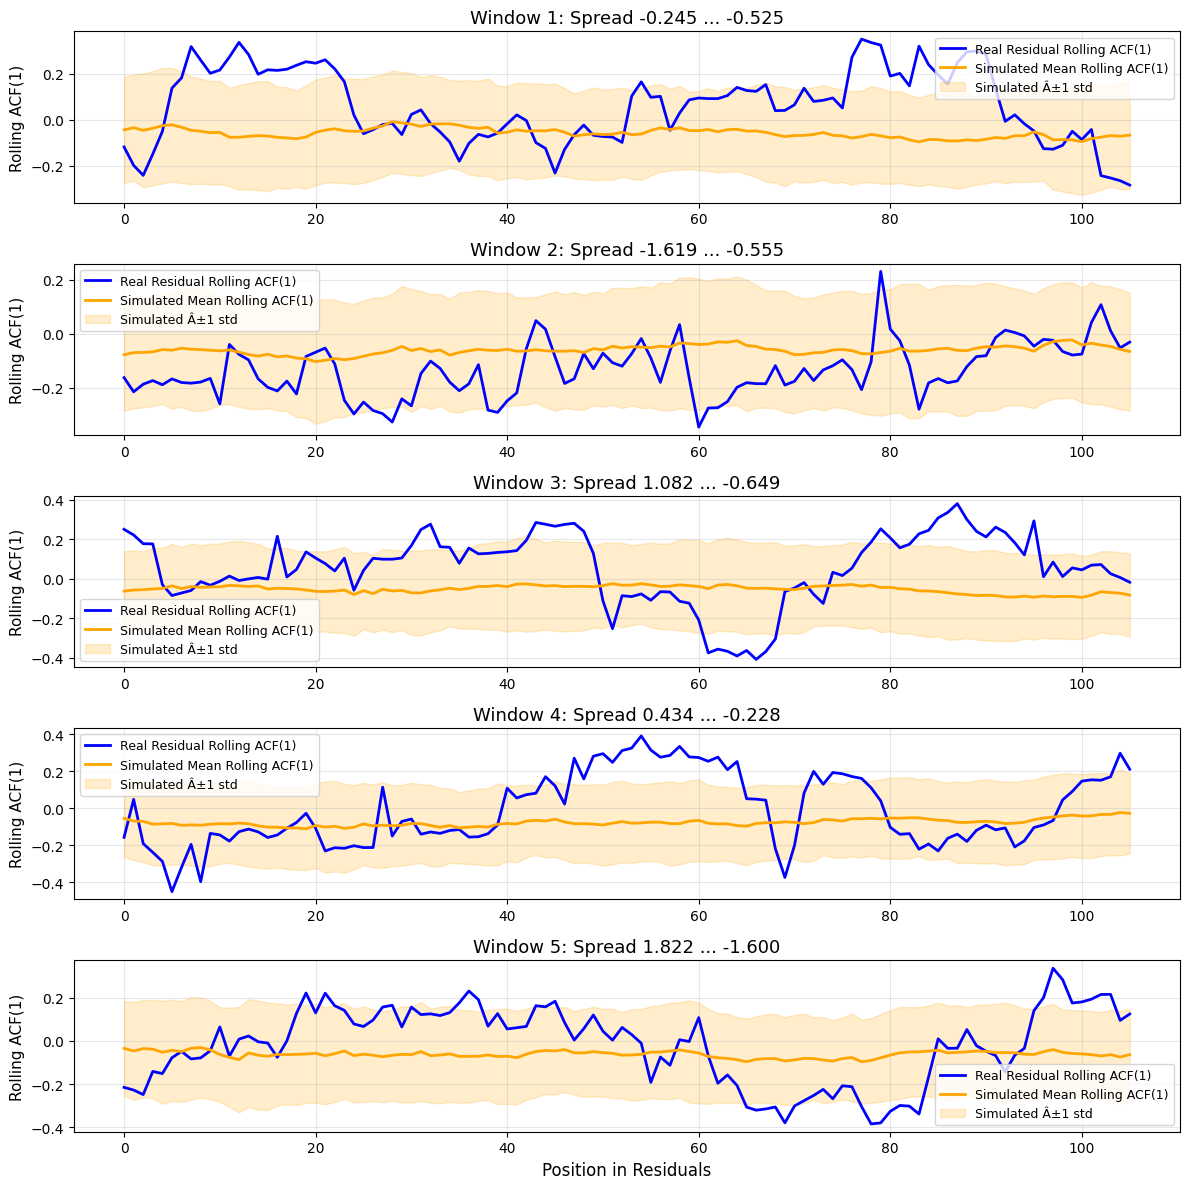

In [26]:
# Residual rolling window autocorrelation analysis for the 5 selected windows (subplots)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

window_size = 20  # Rolling window size for autocorrelation
num_windows = 5
fig, axes = plt.subplots(num_windows, 1, figsize=(12, 12), sharex=False)

for i, res in enumerate(results):
    real_window = res['real_window']
    phi_fit = res['phi_fit']
    mu_fit = np.mean(real_window)
    # Compute AR(1) residuals for real window
    real_resid = real_window[1:] - (mu_fit + phi_fit * (real_window[:-1] - mu_fit))
    # Rolling window autocorrelation (lag 1)
    rolling_acf_real = [pd.Series(real_resid[j:j+window_size]).autocorr(lag=1)
                       for j in range(len(real_resid) - window_size + 1)]
    # Simulated: average rolling autocorr of residuals from 100 synthetic samples
    rolling_acf_sim_all = []
    for _ in range(100):
        sim = generate_ar1_sample(phi_fit, mu_fit, res['synthetic_diag_mean']['sigma'] if 'sigma' in res['synthetic_diag_mean'] else np.std(real_window), n=126)
        sim_resid = sim[1:] - (mu_fit + phi_fit * (sim[:-1] - mu_fit))
        rolling_acf_sim = [pd.Series(sim_resid[j:j+window_size]).autocorr(lag=1)
                          for j in range(len(sim_resid) - window_size + 1)]
        rolling_acf_sim_all.append(rolling_acf_sim)
    rolling_acf_sim_all = np.array(rolling_acf_sim_all)
    rolling_acf_sim_mean = np.nanmean(rolling_acf_sim_all, axis=0)
    rolling_acf_sim_std = np.nanstd(rolling_acf_sim_all, axis=0)
    ax = axes[i]
    ax.plot(rolling_acf_real, label='Real Residual Rolling ACF(1)', color='blue', linewidth=2)
    ax.plot(rolling_acf_sim_mean, label='Simulated Mean Rolling ACF(1)', color='orange', linewidth=2)
    ax.fill_between(range(len(rolling_acf_sim_mean)),
                   rolling_acf_sim_mean - rolling_acf_sim_std,
                   rolling_acf_sim_mean + rolling_acf_sim_std,
                   color='orange', alpha=0.2, label='Simulated Â±1 std')
    ax.set_title(f'Window {i+1}: Spread {real_window[0]:.3f} ... {real_window[-1]:.3f}', fontsize=13)
    ax.set_ylabel('Rolling ACF(1)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Position in Residuals', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Diagnostic Divergence Analysis

We now quantify how much real window diagnostics differ from synthetic AR(1) diagnostics as the CNN score improves.

**Hypothesis:** If the CNN score truly reflects AR(1) admissibility, then high-score windows should exhibit smaller divergence from AR(1) expectations. This would validate the score as a measure of "how AR(1)-like" the window is in its observable structureâ€”the same property `rel_delta_mae` measures by in-sample fit gain, but assessed independently here via shape statistics rather than fit quality.

We compute absolute differences in three key metrics:
- ACF(1) divergence: |real_acf - synthetic_acf|
- Excess kurtosis divergence: |real_kurtosis - synthetic_kurtosis|
- Zero-crossing rate divergence: |real_rate - synthetic_rate|

The average divergence across these three metrics quantifies total diagnostic mismatch.

In [27]:
# Compute diagnostic divergence metrics
print("\n=== Diagnostic Divergence by CNN Score ===")
print("How much do real window diagnostics differ from their fitted AR(1) synthetic?")
print("(Lower divergence → window is more AR(1)-consistent)\n")

divergences = []
for res in results:
    rd   = res['real_diag']
    sd   = res['synthetic_diag_mean']
    div_acf        = abs(rd['acf_lag1']           - sd['acf_lag1'])
    div_kurtosis   = abs(rd['excess_kurtosis']     - sd['excess_kurtosis'])
    div_zero_cross = abs(rd['zero_crossing_rate']  - sd['zero_crossing_rate'])
    avg_div        = float(np.mean([div_acf, div_kurtosis, div_zero_cross]))
    divergences.append({'label': res['label'], 'cnn_score': res.get('cnn_score', None),
                        'div_acf': div_acf, 'div_kurtosis': div_kurtosis,
                        'div_zero_cross': div_zero_cross, 'avg_div': avg_div})
    print(f"  Window (label={res['label']:.4f}):")
    print(f"    ACF divergence        : {div_acf:.4f}")
    print(f"    Kurtosis divergence   : {div_kurtosis:.4f}")
    print(f"    Zero-crossing divergence: {div_zero_cross:.4f}")
    print(f"    Average divergence    : {avg_div:.4f}")

avg_divs = [d['avg_div'] for d in divergences]
print("\nKey Finding:")
if avg_divs[0] > avg_divs[-1]:
    pct = 100 * (avg_divs[0] - avg_divs[-1]) / avg_divs[0]
    print(f"  Diagnostic divergence DECREASES as CNN score improves: {pct:.1f}% reduction")
    print("  This validates the score: high-score windows are closer to AR(1) shape expectations.")
else:
    print("  Mixed pattern — real windows retain structure beyond AR(1) even at high scores.")

print("\n  All selected windows have rel_delta_mae > 0.03 (OU-admissible by the CNN label).")
print("  The CNN gates entry; the live controller handles within-window adaptation.")



=== Diagnostic Divergence by CNN Score ===
How much do real window diagnostics differ from their fitted AR(1) synthetic?
(Lower divergence → window is more AR(1)-consistent)

  Window (label=-0.0001):
    ACF divergence        : 0.0503
    Kurtosis divergence   : 0.2427
    Zero-crossing divergence: 0.0782
    Average divergence    : 0.1237
  Window (label=0.0060):
    ACF divergence        : 0.0391
    Kurtosis divergence   : 0.0854
    Zero-crossing divergence: 0.0622
    Average divergence    : 0.0623
  Window (label=0.0224):
    ACF divergence        : 0.0355
    Kurtosis divergence   : 0.6389
    Zero-crossing divergence: 0.0233
    Average divergence    : 0.2325
  Window (label=0.0304):
    ACF divergence        : 0.0211
    Kurtosis divergence   : 0.1428
    Zero-crossing divergence: 0.0119
    Average divergence    : 0.0586
  Window (label=0.0492):
    ACF divergence        : 0.0350
    Kurtosis divergence   : 0.3970
    Zero-crossing divergence: 0.0109
    Average divergence 

## 8. Detrended Windows: Does the CNN Rely on Trend Detection?

The non-detrended result (AUC 0.9836) raises a question: is the CNN partly gating on the presence or absence of a visible linear trend, rather than on genuine AR(1) structure?

Here we linearly detrend every test window (OLS fit of index against time, then subtract) and re-evaluate:

1. **CNN on detrended windows.** The CNN was trained on raw windows. For windows that already carry near-zero trend, detrending changes the input very little. For windows with a visible trend, detrending removes a morphological feature the CNN may have relied on as a proxy signal. If AUC holds up, the CNN is robust to the trend component. If it drops, the CNN was partly relying on trend morphology.
2. **Simple LR baseline on detrended phi** (phi estimated after detrending). This isolates whether classical OU admissibility judgement improves once the trend is removed.

**What to look for:** Whether the CNN's predictions change materially when the trend is removed from the input. Windows with near-zero trend are unaffected; windows with a visible trend are the informative cases.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

SERIES_COLS = [f"series_{k:03d}" for k in range(126)]
t_idx = np.arange(126, dtype=np.float64)

def detrend_window(series):
    """Remove OLS linear trend from a 126-length window. Returns detrended series and (a, b)."""
    A = np.column_stack([np.ones(126), t_idx])
    coeffs, _, _, _ = np.linalg.lstsq(A, series, rcond=None)
    return series - (coeffs[0] + coeffs[1] * t_idx), coeffs[0], coeffs[1]

# ── Build detrended version of the test set ───────────────────────────────────
print("Detrending all test windows...")
raw = df[SERIES_COLS].values.astype(np.float64)

detrended = np.empty_like(raw)
trend_slopes = np.empty(len(df))
trend_intercepts = np.empty(len(df))

for i in range(len(raw)):
    det, a, b = detrend_window(raw[i])
    detrended[i] = det
    trend_intercepts[i] = a
    trend_slopes[i] = b

df['trend_slope'] = trend_slopes
print(f"Done. Detrended shape: {detrended.shape}")

# ── Feature extraction on detrended windows ───────────────────────────────────
print("\nComputing features on detrended windows...")

phi_det    = np.empty(len(df))
zero_cr_det = np.empty(len(df))

for i, row in enumerate(detrended):
    xc   = row - row.mean()
    a0   = np.mean(xc**2)
    a1   = np.mean(xc[:-1] * xc[1:])
    phi_det[i]     = np.clip(a1 / (a0 + 1e-12), -0.999, 0.999)
    zero_cr_det[i] = np.sum(np.diff(np.sign(xc)) != 0)

df['phi_det']      = phi_det
df['zero_cr_det']  = zero_cr_det

print("Features computed.")
print(f"  phi_det    mean: {phi_det.mean():.4f}  std: {phi_det.std():.4f}")
print(f"  zero_cr_det mean: {zero_cr_det.mean():.4f}  std: {zero_cr_det.std():.4f}")

Detrending all test windows...
Done. Detrended shape: (14432, 126)

Computing features on detrended windows...
Features computed.
  phi_det    mean: 0.9051  std: 0.0474
  zero_cr_det mean: 14.2237  std: 5.9764


In [29]:
# ── CNN inference on detrended windows ───────────────────────────────────────
print("Running CNN on detrended windows...")

s_det = detrended.astype(np.float32)
d_det = np.empty_like(s_det)
d_det[:, 0]  = 0.0
d_det[:, 1:] = np.diff(s_det, axis=1)
X_det = torch.from_numpy(np.stack([s_det, d_det, d_det**2], axis=1))  # (N, 3, 126)

preds_det = []
with torch.no_grad():
    for (xb,) in DataLoader(TensorDataset(X_det), batch_size=1024, shuffle=False):
        preds_det.append(model(xb.to(device)).cpu().numpy())

df['cnn_score_det'] = np.concatenate(preds_det)

y_true = (df['rel_delta_mae'] > 0.03).astype(int)
auc_raw = roc_auc_score(y_true, df['cnn_score'])
auc_det = roc_auc_score(y_true, df['cnn_score_det'])

print(f"\nCNN AUC — raw (non-detrended) windows : {auc_raw:.4f}")
print(f"CNN AUC — detrended windows           : {auc_det:.4f}")
print(f"Delta                                  : {auc_det - auc_raw:+.4f}")

# ── LR baseline: phi from raw vs phi from detrended ──────────────────────────
scaler_raw = StandardScaler()
scaler_det = StandardScaler()

X_lr_raw = scaler_raw.fit_transform(df[['phi_clipped', 'zero_crossings']].values)
X_lr_det = scaler_det.fit_transform(df[['phi_det', 'zero_cr_det']].values)

lr_raw = LogisticRegression(max_iter=1000).fit(X_lr_raw, y_true)
lr_det = LogisticRegression(max_iter=1000).fit(X_lr_det, y_true)

auc_lr_raw = roc_auc_score(y_true, lr_raw.predict_proba(X_lr_raw)[:, 1])
auc_lr_det = roc_auc_score(y_true, lr_det.predict_proba(X_lr_det)[:, 1])

print(f"\nLR baseline (phi + zero_crossings, raw windows)       : {auc_lr_raw:.4f}")
print(f"LR baseline (phi + zero_crossings, detrended windows) : {auc_lr_det:.4f}")
print(f"Delta                                                  : {auc_lr_det - auc_lr_raw:+.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'Method':<40} {'AUC':>6}")
print("="*55)
print(f"{'LR baseline (raw phi + zero_crossings)':<40} {auc_lr_raw:>6.4f}")
print(f"{'LR baseline (detrended phi + zero_cr)':<40} {auc_lr_det:>6.4f}")
print(f"{'CNN (trained & evaluated on raw windows)':<40} {auc_raw:>6.4f}")
print(f"{'CNN (trained on raw, evaluated on detrended)':<40} {auc_det:>6.4f}")
print("="*55)

Running CNN on detrended windows...

CNN AUC — raw (non-detrended) windows : 0.9836
CNN AUC — detrended windows           : 0.9481
Delta                                  : -0.0355

LR baseline (phi + zero_crossings, raw windows)       : 0.8502
LR baseline (phi + zero_crossings, detrended windows) : 0.8207
Delta                                                  : -0.0295

Method                                      AUC
LR baseline (raw phi + zero_crossings)   0.8502
LR baseline (detrended phi + zero_cr)    0.8207
CNN (trained & evaluated on raw windows) 0.9836
CNN (trained on raw, evaluated on detrended) 0.9481


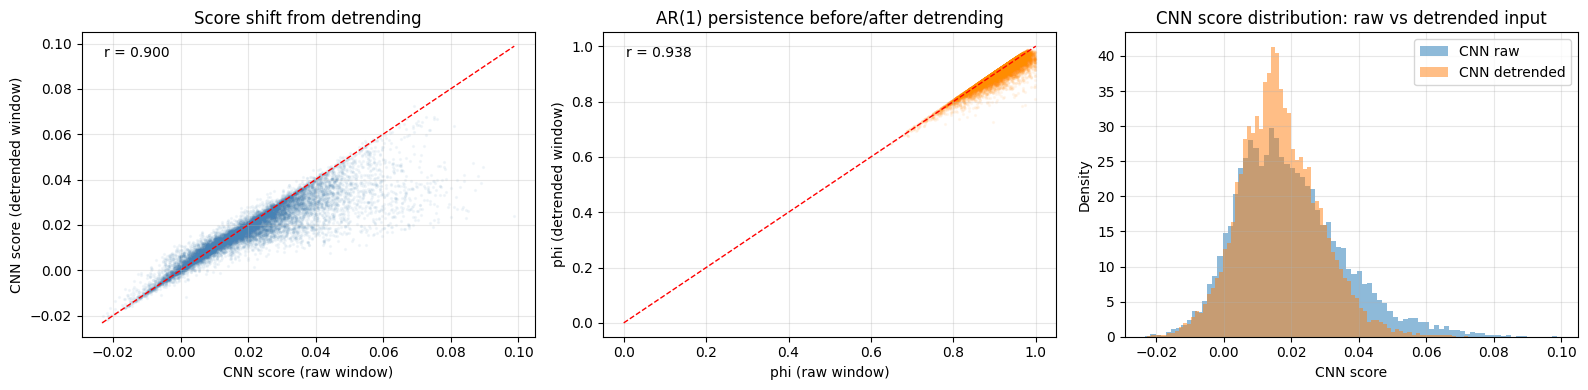

Saved: phase3_detrended_comparison.png


In [30]:
# ── Visualise: CNN score distributions on raw vs detrended ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: CNN score scatter — raw vs detrended
axes[0].scatter(df['cnn_score'], df['cnn_score_det'], alpha=0.05, s=2, color='steelblue')
mn = min(df['cnn_score'].min(), df['cnn_score_det'].min())
mx = max(df['cnn_score'].max(), df['cnn_score_det'].max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1)
axes[0].set_xlabel('CNN score (raw window)')
axes[0].set_ylabel('CNN score (detrended window)')
axes[0].set_title('Score shift from detrending')
axes[0].grid(True, alpha=0.3)
r = np.corrcoef(df['cnn_score'], df['cnn_score_det'])[0, 1]
axes[0].text(0.05, 0.92, f'r = {r:.3f}', transform=axes[0].transAxes, fontsize=10)

# Panel 2: phi_clipped (raw) vs phi_det
axes[1].scatter(df['phi_clipped'], df['phi_det'], alpha=0.05, s=2, color='darkorange')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1)
axes[1].set_xlabel('phi (raw window)')
axes[1].set_ylabel('phi (detrended window)')
axes[1].set_title('AR(1) persistence before/after detrending')
axes[1].grid(True, alpha=0.3)
r2 = np.corrcoef(df['phi_clipped'], df['phi_det'])[0, 1]
axes[1].text(0.05, 0.92, f'r = {r2:.3f}', transform=axes[1].transAxes, fontsize=10)

# Panel 3: label distribution by admissibility (same label, different score)
for label_str, subset in [('CNN raw', df['cnn_score']), ('CNN detrended', df['cnn_score_det'])]:
    axes[2].hist(subset, bins=80, alpha=0.5, label=label_str, density=True)
axes[2].set_xlabel('CNN score')
axes[2].set_ylabel('Density')
axes[2].set_title('CNN score distribution: raw vs detrended input')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_detrended_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: phase3_detrended_comparison.png")

### Discussion: Detrended Performance Drop

**Context:** the label `rel_delta_mae` was computed on detrended windows, while the CNN input is the raw window. Passing detrended windows to the CNN is therefore the experiment that closes the label-input gap: input and label are now both aligned to the detrended series.

Despite this alignment, AUC drops from 0.9836 to 0.9481 (delta -0.0355). The LR baseline drops similarly (0.8502 to 0.8207). Both methods perform worse on detrended input, even though detrended input is closer to what the label measures.

Note that this is not a clean distributional shift: many training windows carried near-zero trend, so their detrended versions look nearly identical to the raw versions and the model has effectively seen them. The performance drop is driven by the subset of windows where detrending meaningfully changes the morphology. For those windows, the CNN was relying on trend-related features in the raw series as a proxy for predicting the detrended-fit quality label. When the trend is removed, those proxy features disappear and prediction degrades.

The LR baseline drops for the same reason: $\hat\phi$ estimated from the detrended window is systematically higher (mean 0.905 vs raw mean), compressing the feature that the classifier relied on.

The result does not tell us whether the CNN correctly detects raw-window AR(1) admissibility. It tells us the CNN learned a mapping from raw morphology to detrended-fit quality, and that mapping degrades when the trend is stripped from the input for windows that carried a non-trivial trend. If the goal is to gate on raw-window AR(1) quality directly, the label should be recomputed on non-detrended windows and the model retrained.

## 9. Summary: Model Diagnostic Validation and Architectural Implications

### What We Did

**Phase 3-C split:** Trained on 511,671 windows from 397 tickers (pre-2020), validated on
61,136 windows from 50 held-out tickers, and evaluated on 14,058 windows from those same
50 held-out tickers restricted to the post-2020 era, capturing unseen tickers and an unseen time
period simultaneously.

**Diagnostic Validation:** Selected five windows across the `cnn_score` spectrum and:
1. Fitted AR(1) to each real window via Yule-Walker
2. Generated 100 synthetic AR(1) samples from the fitted parameters
3. Compared real vs. synthetic diagnostics (ACF, excess kurtosis, zero-crossing rate)
4. Computed divergence metrics to quantify how AR(1)-like each window actually is

**Detrending experiment:** Re-evaluated the CNN and LR baseline on linearly detrended test windows.
This moves the input closer to the label's domain, since the label `rel_delta_mae` was computed
on detrended windows while the CNN was trained on raw windows. Not a clean distributional shift:
windows with near-zero trend are largely unaffected; only trended windows see meaningful input change.

### Key Results

| Metric | Value |
|---|---:|
| LR baseline AUC (raw, phi + zero\_crossings) | 0.8502 |
| CNN AUC @ 0.03 threshold (raw) | 0.9836 |
| CNN Average Precision | 0.9634 |
| CNN R² (regression target) | 0.8926 |
| Delta AUC (CNN $-$ LR, raw) | +0.1334 |
| Stocks AUC (n=3,824) | 0.9843 |
| FF portfolios AUC (n=10,234) | 0.9883 |
| CNN AUC on detrended windows | 0.9481 |
| LR baseline AUC on detrended windows | 0.8207 |

**Label-Diagnostics Correlation.** Diagnostic divergence from AR(1) decreases as `cnn_score`
improves, validating the score independently of the in-sample fit metric used to construct it.

**Residual Structure Remains.** Even the highest-score windows show rolling residual ACF
patterns that pure AR(1) cannot explain. Time-varying dynamics, heteroskedasticity, and regime
shifts are present even on admissible windows, motivating a live sequential controller.

**Detrending drops AUC.** The CNN drops from 0.9836 to 0.9481 when evaluated on detrended windows
(delta -0.0355). The LR baseline drops similarly (0.8502 to 0.8207). The drop is driven by windows
that carried a non-trivial trend: for those windows, detrending removes the morphological proxy
features the CNN relied on. See Section 8 for the full discussion.

